# Generate daily AVISO eddy-overlay frames

Generate one PNG per available AVISO day for later assembly into an animation. Each frame follows `eddy_velocity_overlay.ipynb`: native `ugos`/`vgos` speed and arrows, processed eddy centres and IDs, and the fitted $R_c^2/2$ ESP contour.

The NetCDF files are processed one year at a time, figures are closed immediately, existing frames can be skipped, and a CSV manifest records the animation order.

In [1]:
from pathlib import Path
import sys

import matplotlib.patheffects as pe
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import xarray as xr

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
for source in (PROJECT_ROOT / "src", PROJECT_ROOT.parent / "seacofs_eddy_dataset_modular" / "src"):
    if str(source) not in sys.path:
        sys.path.insert(0, str(source))

from aviso_eddy_dataset.grid import build_grid, native_velocity
plt.ioff()

## Controls

In [2]:
DATA_ROOT = Path("/srv/scratch/z5502183/AVISO_0.125")
PROCESSED_PATH = Path("/srv/scratch/z5297792/aviso_eddy_dataset/processed/eddy_dataset_processed.parquet")
FRAME_DIR = Path("/srv/scratch/z5297792/aviso_eddy_dataset/daily_overlay_frames")
MANIFEST_PATH = FRAME_DIR / "frame_manifest.csv"
FILE_PATTERN = "AVISO_0.125_EAC_*.nc"
DATE_ORIGIN = pd.Timestamp("1990-01-01")

# Set either limit to a date string to render only part of the record.
START_DATE = None
END_DATE = None

OVERWRITE = False
NUM_LABEL = True
SHOW_QUIVER = True
QUIVER_STEP = 3
QUIVER_WIDTH = 0.0015
FIGSIZE = (9, 10)
DPI = 150

# A single limit prevents colour flicker in the animation. Leave as None to
# estimate it from sampled days, or provide a fixed speed in m s^-1.
SPEED_VMAX = None
SPEED_PERCENTILE = 99.0
SAMPLES_PER_FILE = 6

FRAME_DIR.mkdir(parents=True, exist_ok=True)
FRAME_DIR

PosixPath('/srv/scratch/z5297792/aviso_eddy_dataset/daily_overlay_frames')

## Load eddies and source files

In [3]:
if not PROCESSED_PATH.exists():
    raise FileNotFoundError(f"Processed dataset not found: {PROCESSED_PATH}")
df = pd.read_parquet(PROCESSED_PATH)
df["Date"] = pd.to_datetime(df["Date"]).dt.normalize()
df = df.sort_values(["Day", "Eddy"]).reset_index(drop=True)
eddies_by_date = {date: group.copy() for date, group in df.groupby("Date", sort=False)}

source_files = sorted(DATA_ROOT.glob(FILE_PATTERN))
if not source_files:
    raise FileNotFoundError(f"No files matching {FILE_PATTERN!r} under {DATA_ROOT}")
print(f"Processed eddies: {len(df):,} rows, {df.Eddy.nunique():,} tracks")
print(f"Source files: {len(source_files)}")
print(f"Frame directory: {FRAME_DIR}")

Processed eddies: 453,309 rows, 8,979 tracks
Source files: 26
Frame directory: /srv/scratch/z5297792/aviso_eddy_dataset/daily_overlay_frames


## Determine one colour scale for all frames

In [4]:
def estimate_speed_vmax(paths, percentile=SPEED_PERCENTILE, samples_per_file=SAMPLES_PER_FILE):
    sampled_speeds = []
    for path in paths:
        with xr.open_dataset(path, decode_times=True) as dataset:
            sample_count = min(samples_per_file, dataset.sizes["time"])
            indices = np.linspace(0, dataset.sizes["time"] - 1, sample_count, dtype=int)
            for index in np.unique(indices):
                u = np.asarray(dataset.ugos.isel(time=index), dtype=float)
                v = np.asarray(dataset.vgos.isel(time=index), dtype=float)
                speed = np.hypot(u, v)
                sampled_speeds.append(speed[np.isfinite(speed)].ravel())
    if not sampled_speeds:
        raise ValueError("No finite AVISO velocities were found while estimating SPEED_VMAX.")
    return float(np.percentile(np.concatenate(sampled_speeds), percentile))

if SPEED_VMAX is None:
    SPEED_VMAX = estimate_speed_vmax(source_files)
print(f"Shared speed colour limit: 0 to {SPEED_VMAX:.3f} m s^-1")

Shared speed colour limit: 0 to 1.037 m s^-1


## Frame renderer

In [5]:
def render_frame(dataset, time_index, grid, df_day, date, day, output_path):
    u = native_velocity(dataset.ugos.isel(time=time_index), grid)
    v = native_velocity(dataset.vgos.isel(time=time_index), grid)
    speed = np.hypot(u, v)

    fig, ax = plt.subplots(figsize=FIGSIZE, constrained_layout=True)
    image = ax.pcolormesh(
        grid.X_grid, grid.Y_grid, speed, shading="auto",
        vmin=0, vmax=SPEED_VMAX, cmap="Blues_r",
    )
    fig.colorbar(
        image, ax=ax, label=r"Absolute geostrophic current speed (m s$^{-1}$)", shrink=0.7
    )

    if SHOW_QUIVER:
        step = max(1, int(QUIVER_STEP))
        ax.quiver(
            grid.X_grid[::step, ::step], grid.Y_grid[::step, ::step],
            u[::step, ::step], v[::step, ::step],
            color="0.2", alpha=0.55, pivot="mid", width=QUIVER_WIDTH,
        )

    colours = {"AE": "red", "CE": "cyan"}
    for row in df_day.itertuples(index=False):
        colour = colours.get(row.Cyc, "white")
        ax.scatter(
            row.xc, row.yc, color=colour, edgecolor="black",
            linewidth=0.8, s=20, zorder=10,
        )
        if np.all(np.isfinite([row.q11, row.q12, row.q22, row.Rc])):
            Q = np.array([[row.q11, row.q12], [row.q12, row.q22]], dtype=float)
            dx, dy = grid.X_grid - row.xc, grid.Y_grid - row.yc
            rho2 = Q[0, 0] * dx**2 + 2 * Q[0, 1] * dx * dy + Q[1, 1] * dy**2
            ax.contour(
                grid.X_grid, grid.Y_grid, rho2, levels=[row.Rc**2 / 2],
                colors=[colour], linewidths=1.5, zorder=9,
            )
        if NUM_LABEL:
            ax.annotate(
                str(int(row.Eddy)), (row.xc, row.yc), textcoords="offset points",
                xytext=(3, 3), fontsize=8, color="white", weight="bold",
                path_effects=[pe.withStroke(linewidth=2, foreground="black")], zorder=11,
            )

    lon_field = np.broadcast_to(grid.longitude[:, None], grid.X_grid.shape)
    lat_field = np.broadcast_to(grid.latitude[None, :], grid.Y_grid.shape)
    lon_levels = np.arange(np.ceil(grid.longitude.min() / 5) * 5, grid.longitude.max(), 5)
    lat_levels = np.arange(np.ceil(grid.latitude.min() / 5) * 5, grid.latitude.max(), 5)
    if lat_levels.size:
        contours = ax.contour(
            grid.X_grid, grid.Y_grid, lat_field, levels=lat_levels,
            colors="black", linewidths=0.5, alpha=0.7,
        )
        ax.clabel(contours, fmt=lambda value: f"{abs(value):.0f}°S", fontsize=8)
    if lon_levels.size:
        contours = ax.contour(
            grid.X_grid, grid.Y_grid, lon_field, levels=lon_levels,
            colors="black", linewidths=0.5, alpha=0.7,
        )
        ax.clabel(contours, fmt=lambda value: f"{value:.0f}°E", fontsize=8)

    ae_count = int(df_day.Cyc.eq("AE").sum()) if not df_day.empty else 0
    ce_count = int(df_day.Cyc.eq("CE").sum()) if not df_day.empty else 0
    ax.set(
        title=f"AVISO eddies | Day {day} | {date:%Y-%m-%d} | AE={ae_count}, CE={ce_count}",
        xlabel="x (km)", ylabel="y (km)",
        xlim=(grid.x_grid.min(), grid.x_grid.max()),
        ylim=(grid.y_grid.min(), grid.y_grid.max()), aspect="equal",
    )
    fig.savefig(output_path, dpi=DPI, facecolor="white")
    plt.close(fig)
    return ae_count, ce_count

## Generate frames

Files are named with a zero-padded global frame number followed by the date, so lexical order is animation order. Rerunning with `OVERWRITE=False` resumes without redrawing completed frames.

KeyboardInterrupt: 

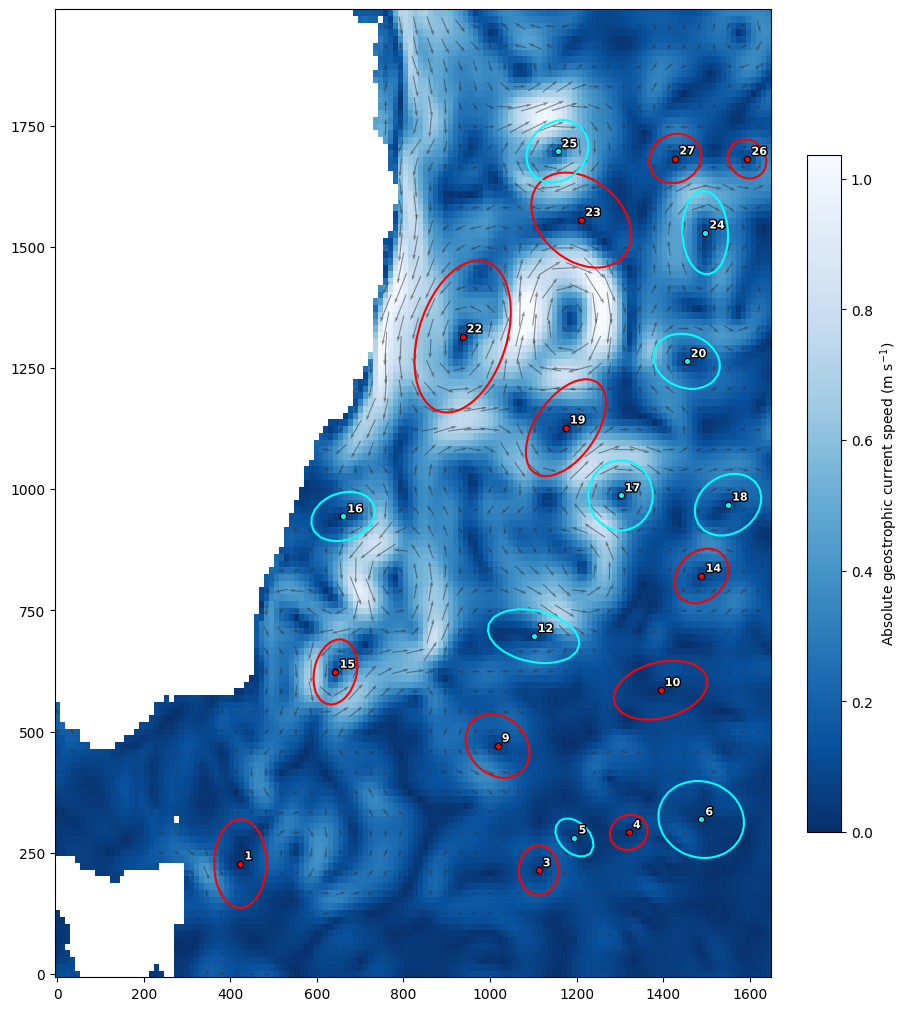

In [6]:
start = pd.Timestamp(START_DATE).normalize() if START_DATE else None
end = pd.Timestamp(END_DATE).normalize() if END_DATE else None
empty_day = df.iloc[0:0].copy()
records = []
frame_number = 0
seen_dates = set()

for source_file in source_files:
    with xr.open_dataset(source_file, decode_times=True) as dataset:
        grid = build_grid(dataset.longitude.values, dataset.latitude.values)
        dates = pd.DatetimeIndex(dataset.time.values).normalize()
        for time_index, date in enumerate(dates):
            if date in seen_dates:
                raise ValueError(f"Duplicate AVISO date across source files: {date:%Y-%m-%d}")
            seen_dates.add(date)
            if (start is not None and date < start) or (end is not None and date > end):
                continue

            day = int((date - DATE_ORIGIN).days)
            df_day = eddies_by_date.get(date, empty_day)
            frame_path = FRAME_DIR / f"frame_{frame_number:06d}_{date:%Y-%m-%d}.png"
            status = "skipped"
            if OVERWRITE or not frame_path.exists():
                ae_count, ce_count = render_frame(
                    dataset, time_index, grid, df_day, date, day, frame_path
                )
                status = "written"
            else:
                ae_count = int(df_day.Cyc.eq("AE").sum()) if not df_day.empty else 0
                ce_count = int(df_day.Cyc.eq("CE").sum()) if not df_day.empty else 0

            records.append(
                {
                    "frame": frame_number, "date": date, "day": day,
                    "source_file": str(source_file), "time_index": time_index,
                    "frame_path": str(frame_path), "AE": ae_count, "CE": ce_count,
                    "status": status,
                }
            )
            frame_number += 1
            if frame_number % 50 == 0:
                print(f"Completed {frame_number:,} frames through {date:%Y-%m-%d}")

manifest = pd.DataFrame(records).sort_values("frame").reset_index(drop=True)
manifest.to_csv(MANIFEST_PATH, index=False)
print(f"Finished {len(manifest):,} frames. Manifest: {MANIFEST_PATH}")
manifest.tail()

## Generation summary

In [ ]:
pd.Series(
    {
        "frames": len(manifest),
        "first_date": manifest.date.min(),
        "last_date": manifest.date.max(),
        "written_this_run": manifest.status.eq("written").sum(),
        "skipped_existing": manifest.status.eq("skipped").sum(),
        "frame_directory": str(FRAME_DIR),
        "speed_vmax_m_s": SPEED_VMAX,
    }, name="value"
).to_frame()